In [29]:
import pandas as pd
df = pd.read_csv('dataset/retail_store_inventory.csv')

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                73100 non-null  object 
 1   Store ID            73100 non-null  object 
 2   Product ID          73100 non-null  object 
 3   Category            73100 non-null  object 
 4   Region              73100 non-null  object 
 5   Inventory Level     73100 non-null  int64  
 6   Units Sold          73100 non-null  int64  
 7   Units Ordered       73100 non-null  int64  
 8   Demand Forecast     73100 non-null  float64
 9   Price               73100 non-null  float64
 10  Discount            73100 non-null  int64  
 11  Weather Condition   73100 non-null  object 
 12  Holiday/Promotion   73100 non-null  int64  
 13  Competitor Pricing  73100 non-null  float64
 14  Seasonality         73100 non-null  object 
dtypes: float64(3), int64(5), object(7)
memory usage: 8.4+

In [31]:
df.shape

(73100, 15)

In [32]:
print("\n=== DTYPES ===")
print(df.dtypes)


=== DTYPES ===
Date                   object
Store ID               object
Product ID             object
Category               object
Region                 object
Inventory Level         int64
Units Sold              int64
Units Ordered           int64
Demand Forecast       float64
Price                 float64
Discount                int64
Weather Condition      object
Holiday/Promotion       int64
Competitor Pricing    float64
Seasonality            object
dtype: object


In [33]:
# ── 3. MISSING VALUES ─────────────────────────────────────────────────────────
print("\n=== NULL COUNTS ===")
print(df.isnull().sum())
print("\nNull percentage per column:")
print((df.isnull().sum() / len(df) * 100).round(2))

print("\nEmpty strings (look like filled but are blank):")
print((df == '').sum())

print("\nWhitespace-only strings:")
for col in df.select_dtypes(include='object').columns:
    count = df[col].astype(str).str.strip().eq('').sum()
    if count > 0:
        print(f"  {col}: {count} rows")


=== NULL COUNTS ===
Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
Inventory Level       0
Units Sold            0
Units Ordered         0
Demand Forecast       0
Price                 0
Discount              0
Weather Condition     0
Holiday/Promotion     0
Competitor Pricing    0
Seasonality           0
dtype: int64

Null percentage per column:
Date                  0.0
Store ID              0.0
Product ID            0.0
Category              0.0
Region                0.0
Inventory Level       0.0
Units Sold            0.0
Units Ordered         0.0
Demand Forecast       0.0
Price                 0.0
Discount              0.0
Weather Condition     0.0
Holiday/Promotion     0.0
Competitor Pricing    0.0
Seasonality           0.0
dtype: float64

Empty strings (look like filled but are blank):
Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
Inv

In [34]:
# Negative Units Sold
neg_units_sold = df[df['Units Sold'] < 0]
print(f"Negative Units Sold rows: {len(neg_units_sold)}")

Negative Units Sold rows: 0


In [35]:
# Negative Inventory
neg_inventory = df[df['Inventory Level'] < 0]
print(f"Negative Inventory rows: {len(neg_inventory)}")


Negative Inventory rows: 0


In [36]:
# Duplicate rows
duplicate_rows = df[df.duplicated()]
print(f"Duplicate rows: {len(duplicate_rows)}")

Duplicate rows: 0


In [37]:
# Date continuity (check missing dates per store)
df['Date'] = pd.to_datetime(df['Date'])
stores = df['Store ID'].unique()
for store in stores:
    store_dates = df[df['Store ID'] == store]['Date'].sort_values()
    missing_dates = pd.date_range(store_dates.min(), store_dates.max()).difference(store_dates)
    print(f"Store {store} - Missing dates: {len(missing_dates)}")

Store S001 - Missing dates: 0
Store S002 - Missing dates: 0
Store S003 - Missing dates: 0
Store S004 - Missing dates: 0
Store S005 - Missing dates: 0


In [38]:
# Outlier detection (IQR) for numeric columns
numeric_cols = ['Inventory Level', 'Units Sold', 'Units Ordered', 'Price', 'Discount', 'Demand Forecast', 'Competitor Pricing']
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    print(f"{col} - Outliers: {len(outliers)}")

Inventory Level - Outliers: 0
Units Sold - Outliers: 715
Units Ordered - Outliers: 0
Price - Outliers: 0
Discount - Outliers: 0
Demand Forecast - Outliers: 732
Competitor Pricing - Outliers: 0


In [39]:
# ── 4. LOGICAL CONSISTENCY ──────────────────────────────────────────────────
print("\n=== INVENTORY BALANCE ===")
# Check if inventory + units ordered >= units sold (basic logic)
imbalance = df[df['Inventory Level'] + df['Units Ordered'] < df['Units Sold']]
print(f"Rows where Inventory + Ordered < Sold: {len(imbalance)}")

print("\n=== PRICE VALIDATION ===")
negative_prices = df[df['Price'] <= 0]
print(f"Non-positive prices: {len(negative_prices)}")

print("\n=== DISCOUNT VALIDATION ===")
invalid_discount = df[(df['Discount'] < 0) | (df['Discount'] > 100)]
print(f"Discounts outside 0-100 range: {len(invalid_discount)}")


=== INVENTORY BALANCE ===
Rows where Inventory + Ordered < Sold: 0

=== PRICE VALIDATION ===
Non-positive prices: 0

=== DISCOUNT VALIDATION ===
Discounts outside 0-100 range: 0


In [40]:
# ── 5. STATISTICAL VALIDATION (Z-SCORE OUTLIERS) ────────────────────────────
from scipy import stats
print("\n=== Z-SCORE OUTLIERS (|Z| > 3) ===")
for col in numeric_cols:
    z_scores = stats.zscore(df[col].dropna())
    z_outliers = (abs(z_scores) > 3).sum()
    print(f"{col} - Z-score outliers: {z_outliers}")


=== Z-SCORE OUTLIERS (|Z| > 3) ===
Inventory Level - Z-score outliers: 0
Units Sold - Z-score outliers: 236
Units Ordered - Z-score outliers: 0
Price - Z-score outliers: 0
Discount - Z-score outliers: 0
Demand Forecast - Z-score outliers: 241
Competitor Pricing - Z-score outliers: 0



=== CORRELATION ANALYSIS ===
Full Correlation Matrix:
                    Inventory Level  Units Sold  Units Ordered  Price  \
Inventory Level               1.000       0.590          0.001  0.009   
Units Sold                    0.590       1.000         -0.001  0.001   
Units Ordered                 0.001      -0.001          1.000  0.004   
Price                         0.009       0.001          0.004  1.000   
Discount                      0.005       0.003         -0.001  0.002   
Demand Forecast               0.589       0.997         -0.001  0.001   
Competitor Pricing            0.009       0.001          0.005  0.994   

                    Discount  Demand Forecast  Competitor Pricing  
Inventory Level        0.005            0.589               0.009  
Units Sold             0.003            0.997               0.001  
Units Ordered         -0.001           -0.001               0.005  
Price                  0.002            0.001               0.994  
Discount            

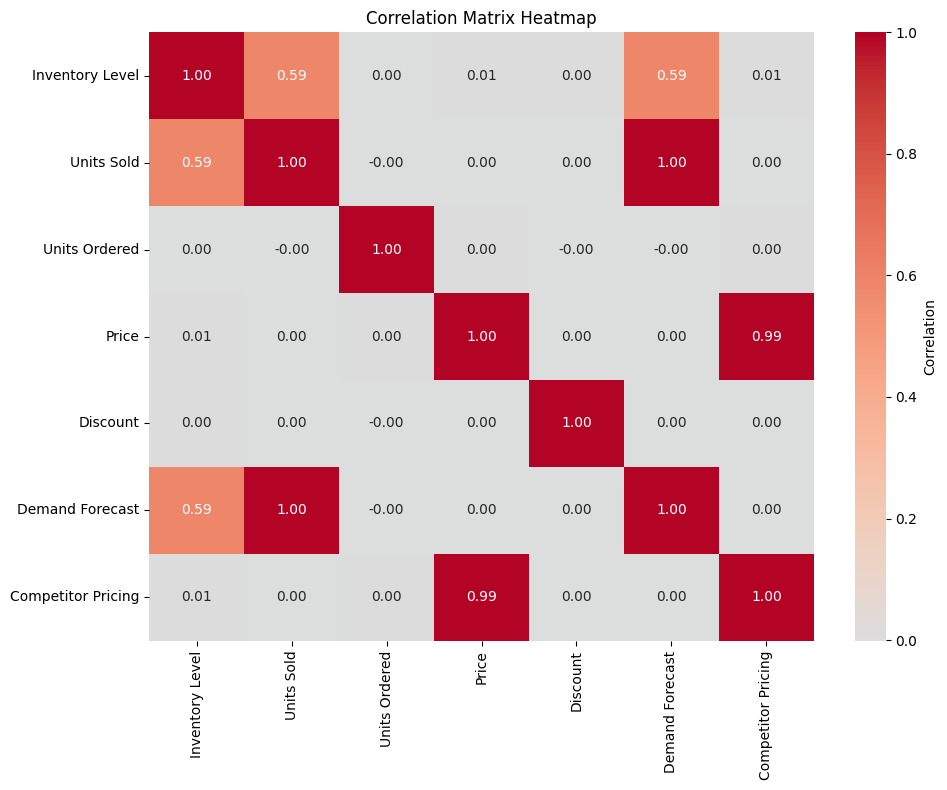

In [52]:
# ── 6. CORRELATION ANALYSIS ────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

print("\n=== CORRELATION ANALYSIS ===")
correlation_matrix = df[numeric_cols].corr()

print("Full Correlation Matrix:")
print(correlation_matrix.round(3))

print("\n\nCorrelation with Units Sold:")
print(correlation_matrix['Units Sold'].sort_values(ascending=False))

print("\nPrice vs Competitor Pricing correlation:")
print(f"{df['Price'].corr(df['Competitor Pricing']):.3f}")

# Heatmap visualization
print("\n📊 CORRELATION MATRIX HEATMAP: Visual representation of relationships between all numeric variables, highlighting which factors most strongly influence sales.")
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', cbar_kws={'label': 'Correlation'})
plt.title('Correlation Matrix Heatmap')
plt.tight_layout()
plt.show()

In [42]:
# ── 7. BUSINESS LOGIC TESTS ────────────────────────────────────────────────
print("\n=== STORE PRODUCTIVITY ===")
store_sales = df.groupby('Store ID')['Units Sold'].sum()
print(f"Stores with zero sales: {(store_sales == 0).sum()}")
print(f"Stores with very low sales (<10 units total): {(store_sales < 10).sum()}")

print("\n=== STOCK-OUT PATTERNS ===")
stockouts = df[(df['Inventory Level'] == 0) & (df['Demand Forecast'] > 0)]
print(f"Stockout events with positive demand: {len(stockouts)}")

print("\n=== OVER-ORDERING CHECK ===")
over_ordered = df[df['Units Ordered'] > df['Demand Forecast'] * 1.5]
print(f"Orders exceeding 1.5x forecast: {len(over_ordered)}")


=== STORE PRODUCTIVITY ===
Stores with zero sales: 0
Stores with very low sales (<10 units total): 0

=== STOCK-OUT PATTERNS ===
Stockout events with positive demand: 0

=== OVER-ORDERING CHECK ===
Orders exceeding 1.5x forecast: 24089


In [43]:
# ── 8. FORECAST ACCURACY ────────────────────────────────────────────────────
print("\n=== DEMAND FORECAST ACCURACY ===")
df['Forecast Error'] = abs(df['Demand Forecast'] - df['Units Sold'])
df['Forecast Error %'] = (df['Forecast Error'] / df['Demand Forecast'].replace(0, 1)) * 100

print(f"Mean absolute error: {df['Forecast Error'].mean():.2f} units")
print(f"Median absolute error: {df['Forecast Error'].median():.2f} units")
print(f"Mean error percentage: {df['Forecast Error %'].mean():.2f}%")

high_error = df[df['Forecast Error %'] > 50]
print(f"Forecasts off by >50%: {len(high_error)}")


=== DEMAND FORECAST ACCURACY ===
Mean absolute error: 8.34 units
Median absolute error: 7.48 units
Mean error percentage: 14.57%
Forecasts off by >50%: 3851


## 9. Temporal Analysis Visualizations

Temporal analysis examines how sales, inventory, and business metrics change over time, revealing seasonal patterns, demand cycles, and anomalies. Understanding these time-based patterns is crucial for:

- **Demand Planning**: Identify peak seasons vs. low seasons to adjust inventory and staffing
- **Anomaly Detection**: Spot unusual sales spikes or drops that may indicate promotions, external events, or data quality issues
- **Operational Efficiency**: Optimize ordering, warehousing, and staffing schedules based on temporal trends
- **Forecasting Improvement**: Incorporate seasonal and cyclical factors to enhance predictive models

The following sections analyze:
- **Average Sales by Day of Week**: Understand if specific days drive higher demand
- **Average Inventory by Month**: Monitor seasonal inventory adjustment patterns
- **Sales Spikes Detection Over Time**: Identify and quantify anomalous sales events
- **Stockout Events by Month**: Track inventory gaps and prevent missed sales opportunities


=== TEMPORAL ANALYSIS WITH VISUALIZATIONS ===

Average sales by day of week:
Day of Week
0    135.09
1    137.31
2    136.62
3    137.28
4    136.85
5    135.31
6    136.81
Name: Units Sold, dtype: float64

Average inventory by month:
Month
1     273.58
2     274.77
3     274.27
4     273.45
5     271.37
6     276.56
7     276.55
8     272.54
9     276.14
10    276.88
11    276.47
12    271.27
Name: Inventory Level, dtype: float64

Detected sales spikes (>2 std dev from 7-day MA): 16159


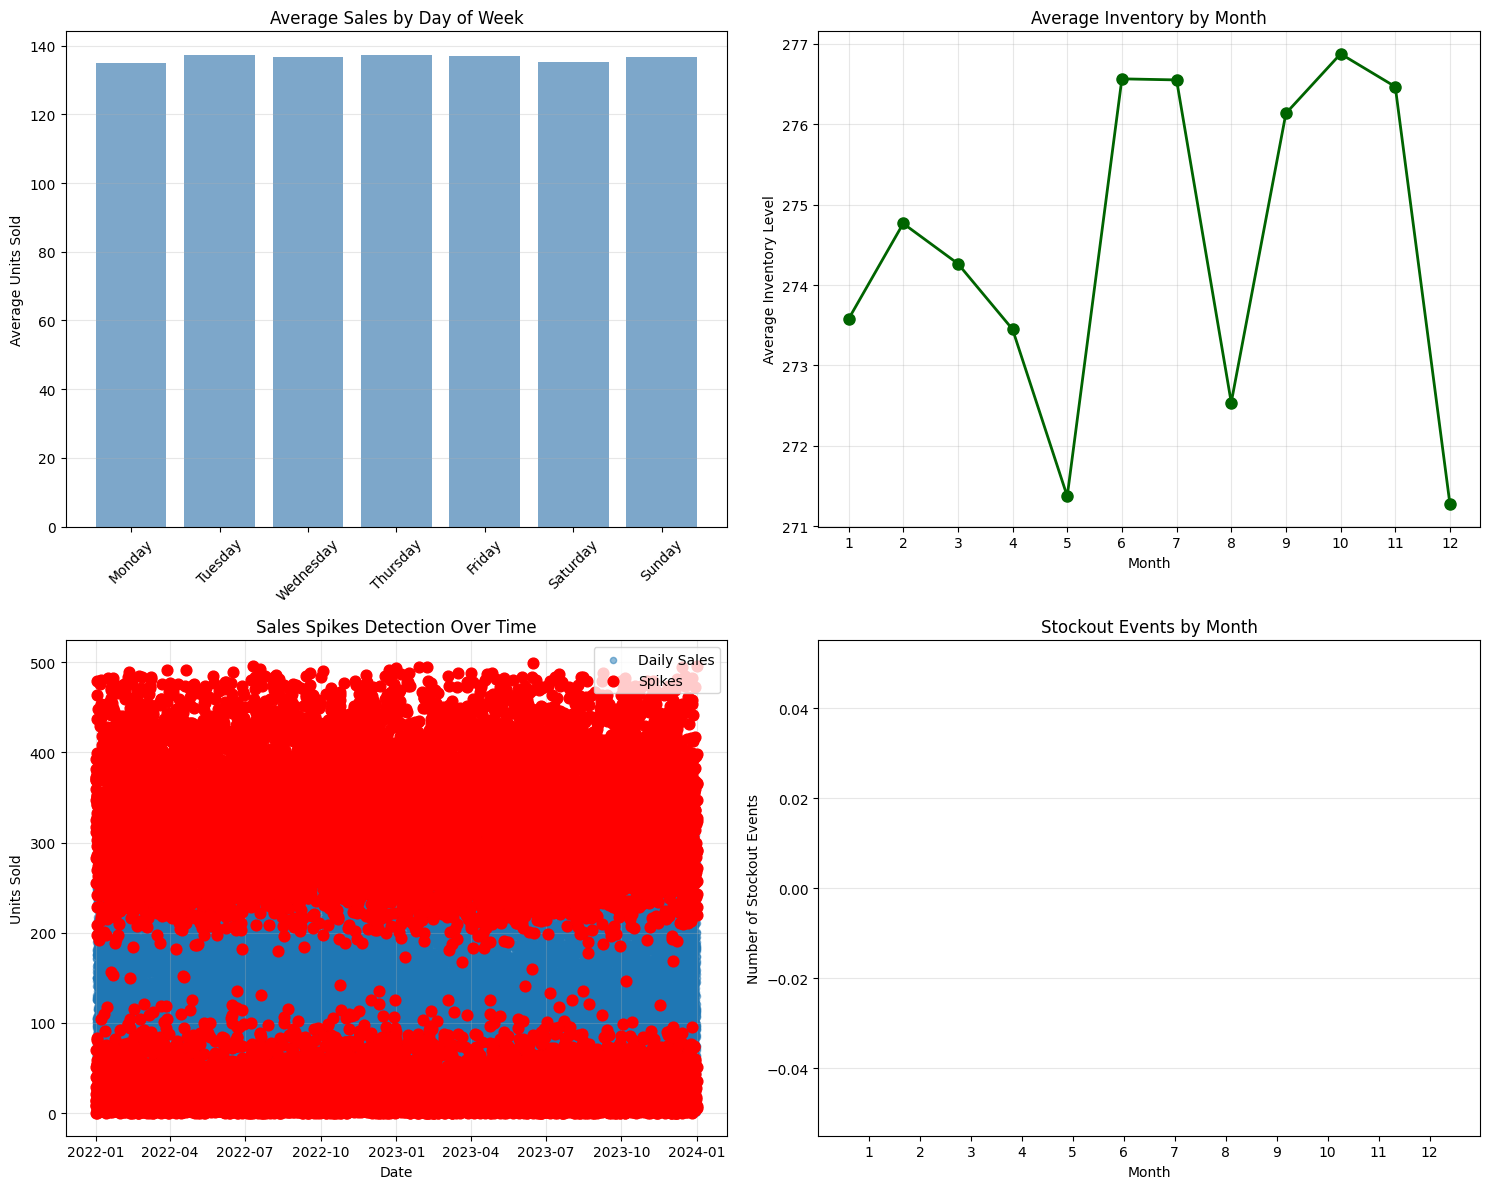


✓ Temporal visualizations created!


In [ ]:
# ── 9. TEMPORAL PATTERNS ────────────────────────────────────────────────────
print("\n=== TEMPORAL ANALYSIS WITH VISUALIZATIONS ===")
df['Day of Week'] = df['Date'].dt.dayofweek
df['Month'] = df['Date'].dt.month

day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

print("\nAverage sales by day of week:")
sales_by_day = df.groupby('Day of Week')['Units Sold'].mean()
print(sales_by_day.round(2))

print("\nAverage inventory by month:")
inv_by_month = df.groupby('Month')['Inventory Level'].mean()
print(inv_by_month.round(2))

# Detect sudden demand spikes (>2 std dev from moving average)
df['Sales MA'] = df.groupby('Store ID')['Units Sold'].transform(lambda x: x.rolling(7, min_periods=1).mean())
df['Sales Deviation'] = abs(df['Units Sold'] - df['Sales MA'])
spikes = df[df['Sales Deviation'] > df['Sales Deviation'].std() * 2]
print(f"\nDetected sales spikes (>2 std dev from 7-day MA): {len(spikes)}")

# Create visualizations
print("\n📈 TEMPORAL PATTERN ANALYSIS: Four charts revealing when demand peaks, how inventory fluctuates seasonally, unusual sales spikes, and critical stockout periods by month.")
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Sales by Day of Week
axes[0, 0].bar(range(7), sales_by_day.values, color='steelblue', alpha=0.7)
axes[0, 0].set_xticks(range(7))
axes[0, 0].set_xticklabels(day_names, rotation=45)
axes[0, 0].set_ylabel('Average Units Sold')
axes[0, 0].set_title('Average Sales by Day of Week')
axes[0, 0].grid(axis='y', alpha=0.3)

# 2. Inventory by Month
axes[0, 1].plot(inv_by_month.index, inv_by_month.values, marker='o', linewidth=2, markersize=8, color='darkgreen')
axes[0, 1].set_xlabel('Month')
axes[0, 1].set_ylabel('Average Inventory Level')
axes[0, 1].set_title('Average Inventory by Month')
axes[0, 1].grid(alpha=0.3)
axes[0, 1].set_xticks(range(1, 13))

# 3. Sales Spikes Over Time
df_sorted = df.sort_values('Date')
axes[1, 0].scatter(df_sorted['Date'], df_sorted['Units Sold'], alpha=0.5, s=20, label='Daily Sales')
spike_indices = spikes.index
if len(spike_indices) > 0:
    axes[1, 0].scatter(df.loc[spike_indices, 'Date'], df.loc[spike_indices, 'Units Sold'], 
                       color='red', s=60, label='Spikes', zorder=5)
axes[1, 0].set_xlabel('Date')
axes[1, 0].set_ylabel('Units Sold')
axes[1, 0].set_title('Sales Spikes Detection Over Time')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# 4. Stockout Events by Month
stockouts = df[(df['Inventory Level'] == 0) & (df['Demand Forecast'] > 0)]
stockouts_by_month = stockouts.groupby('Month').size()
all_months = pd.Series(range(1, 13))
stockouts_by_month = stockouts_by_month.reindex(all_months, fill_value=0)

axes[1, 1].bar(stockouts_by_month.index, stockouts_by_month.values, color='coral', alpha=0.7)
axes[1, 1].set_xlabel('Month')
axes[1, 1].set_ylabel('Number of Stockout Events')
axes[1, 1].set_title('Stockout Events by Month')
axes[1, 1].grid(axis='y', alpha=0.3)
axes[1, 1].set_xticks(range(1, 13))

plt.tight_layout()
plt.show()

print("\n✓ Temporal visualizations created!")

## 10. Inventory Turnover & Efficiency Analysis

Inventory turnover metrics reveal how efficiently stores manage inventory relative to sales, identifying working capital optimization opportunities.


=== INVENTORY TURNOVER & EFFICIENCY METRICS ===

Inventory Efficiency by Store (Top 5):
          Units Sold  Inventory Level  Units Ordered  Turnover Ratio  \
Store ID                                                               
S003         2022696           276.87        1605039         7305.58   
S002         1987715           273.33        1605169         7272.22   
S005         2010176           276.50        1608902         7270.08   
S004         1979245           272.30        1608340         7268.62   
S001         1975750           273.34        1613877         7228.18   

          Days Inventory  
Store ID                  
S003                 0.0  
S002                 0.0  
S005                 0.0  
S004                 0.0  
S001                 0.0  

Overall Metrics:
Total Units Sold: 9,975,582
Average Inventory Level: 274.47 units
Inventory Turnover Ratio: 36344.91x
Days Inventory Outstanding: 0.0 days


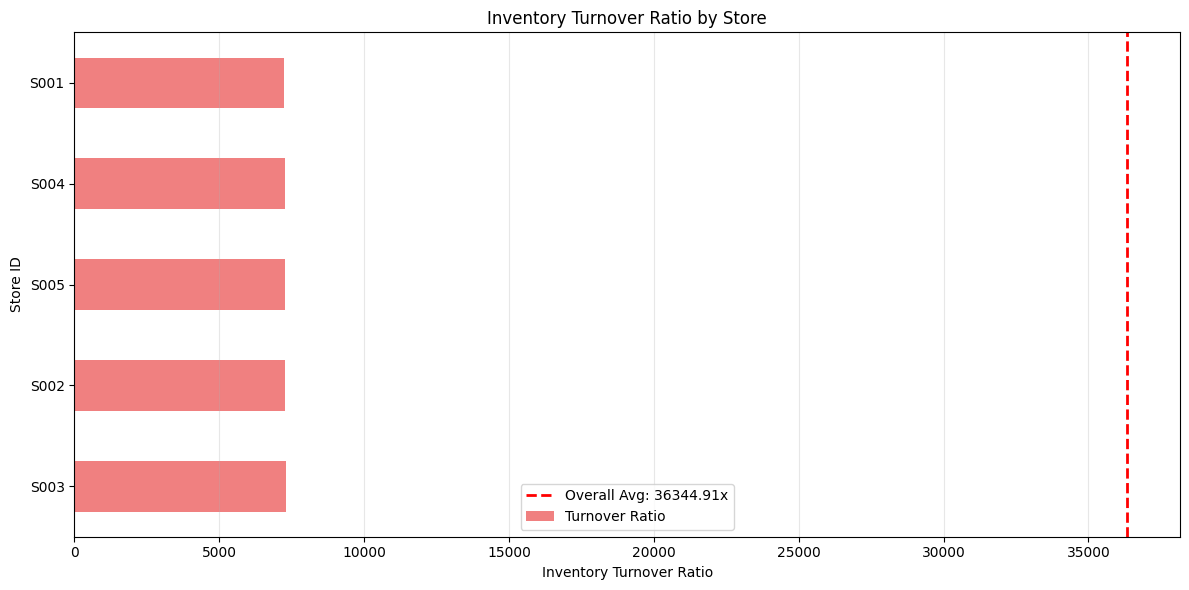


✓ Inventory turnover analysis complete!


In [ ]:
# ── 10. INVENTORY TURNOVER ANALYSIS ───────────────────────────────────────
print("\n=== INVENTORY TURNOVER & EFFICIENCY METRICS ===")

# Calculate inventory metrics by store
store_inventory = df.groupby('Store ID').agg({
    'Units Sold': 'sum',
    'Inventory Level': 'mean',
    'Units Ordered': 'sum'
}).round(2)

# Inventory Turnover = Total Sales / Average Inventory
store_inventory['Turnover Ratio'] = (store_inventory['Units Sold'] / store_inventory['Inventory Level']).round(2)

# Days Inventory Outstanding (DIO) = 365 / Turnover Ratio (months approximated)
store_inventory['Days Inventory'] = (30 / store_inventory['Turnover Ratio']).round(1)  # for monthly view

store_inventory = store_inventory.sort_values('Turnover Ratio', ascending=False)

print("\nInventory Efficiency by Store (Top 5):")
print(store_inventory.head(5))

# Overall metrics
total_sales = df['Units Sold'].sum()
avg_inventory = df['Inventory Level'].mean()
overall_turnover = (total_sales / avg_inventory).round(2)
overall_dio = (30 / overall_turnover).round(1)

print(f"\nOverall Metrics:")
print(f"Total Units Sold: {total_sales:,.0f}")
print(f"Average Inventory Level: {avg_inventory:.2f} units")
print(f"Inventory Turnover Ratio: {overall_turnover:.2f}x")
print(f"Days Inventory Outstanding: {overall_dio:.1f} days")

# Visualization: Turnover Ratio by Store
print("\n🔄 INVENTORY TURNOVER COMPARISON: Bar chart showing which stores move inventory most efficiently relative to sales, benchmarked against the overall average.")
fig, ax = plt.subplots(figsize=(12, 6))
store_inventory['Turnover Ratio'].plot(kind='barh', ax=ax, color='lightcoral')
ax.set_xlabel('Inventory Turnover Ratio')
ax.set_ylabel('Store ID')
ax.set_title('Inventory Turnover Ratio by Store')
ax.axvline(overall_turnover, color='red', linestyle='--', linewidth=2, label=f'Overall Avg: {overall_turnover:.2f}x')
ax.legend()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n✓ Inventory turnover analysis complete!")

## 11. Discount Impact Analysis by Store

This section analyzes how discounts influence sales performance across different stores. Understanding the discount elasticity for each store helps optimize pricing strategies and identify which stores benefit most from promotional discounts.

Key metrics include:
- **Average Discount by Store**: Monitor which stores rely more heavily on discounting
- **Discount vs Sales Correlation**: Determine if discounts drive sales or cannibalize full-price revenue
- **Sales Uplift by Discount Tier**: Quantify the impact of different discount levels on units sold
- **Store-Specific Discount Effectiveness**: Identify best-performing discount strategies per store


=== DISCOUNT IMPACT ANALYSIS BY STORE ===

Discount & Sales Summary by Store:
          Avg Discount (%)  Min Discount (%)  Max Discount (%)  \
Store ID                                                         
S003                 10.11                 0                20   
S002                 10.04                 0                20   
S004                 10.01                 0                20   
S005                  9.97                 0                20   
S001                  9.92                 0                20   

          Avg Sales (units)  Avg Price  
Store ID                                
S003                 138.35      55.08  
S002                 135.96      55.11  
S004                 135.38      55.12  
S005                 137.49      55.25  
S001                 135.14      55.11  


Discount-Sales Correlation by Store:
Store ID  Discount-Sales Correlation
    S002                    0.017687
    S005                    0.007917
    S001             

C:\Users\onsel\AppData\Local\Temp\ipykernel_2788\1844752353.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  discount_tier_analysis = df.groupby(['Store ID', 'Discount Tier']).agg({
C:\Users\onsel\AppData\Local\Temp\ipykernel_2788\1844752353.py:66: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  discount_tier_sales = df.groupby('Discount Tier')['Units Sold'].mean().sort_values()




Sales Performance by Discount Tier & Store:
                        Frequency  Avg Units Sold  Avg Price
Store ID Discount Tier                                      
S001     No Discount         2958          134.10      54.88
         1-5%                2946          135.66      55.15
         6-10%               2938          136.20      54.85
         11-15%              2923          136.95      54.57
         >15%                2855          132.73      56.13
S002     No Discount         2861          129.51      55.50
         1-5%                2975          137.21      55.52
         6-10%               2872          138.73      55.20
         11-15%              3004          138.29      55.33
         >15%                2908          135.88      53.98
S003     No Discount         2876          140.14      54.76
         1-5%                2899          138.51      54.84
         6-10%               2900          137.97      55.22
         11-15%              2931      

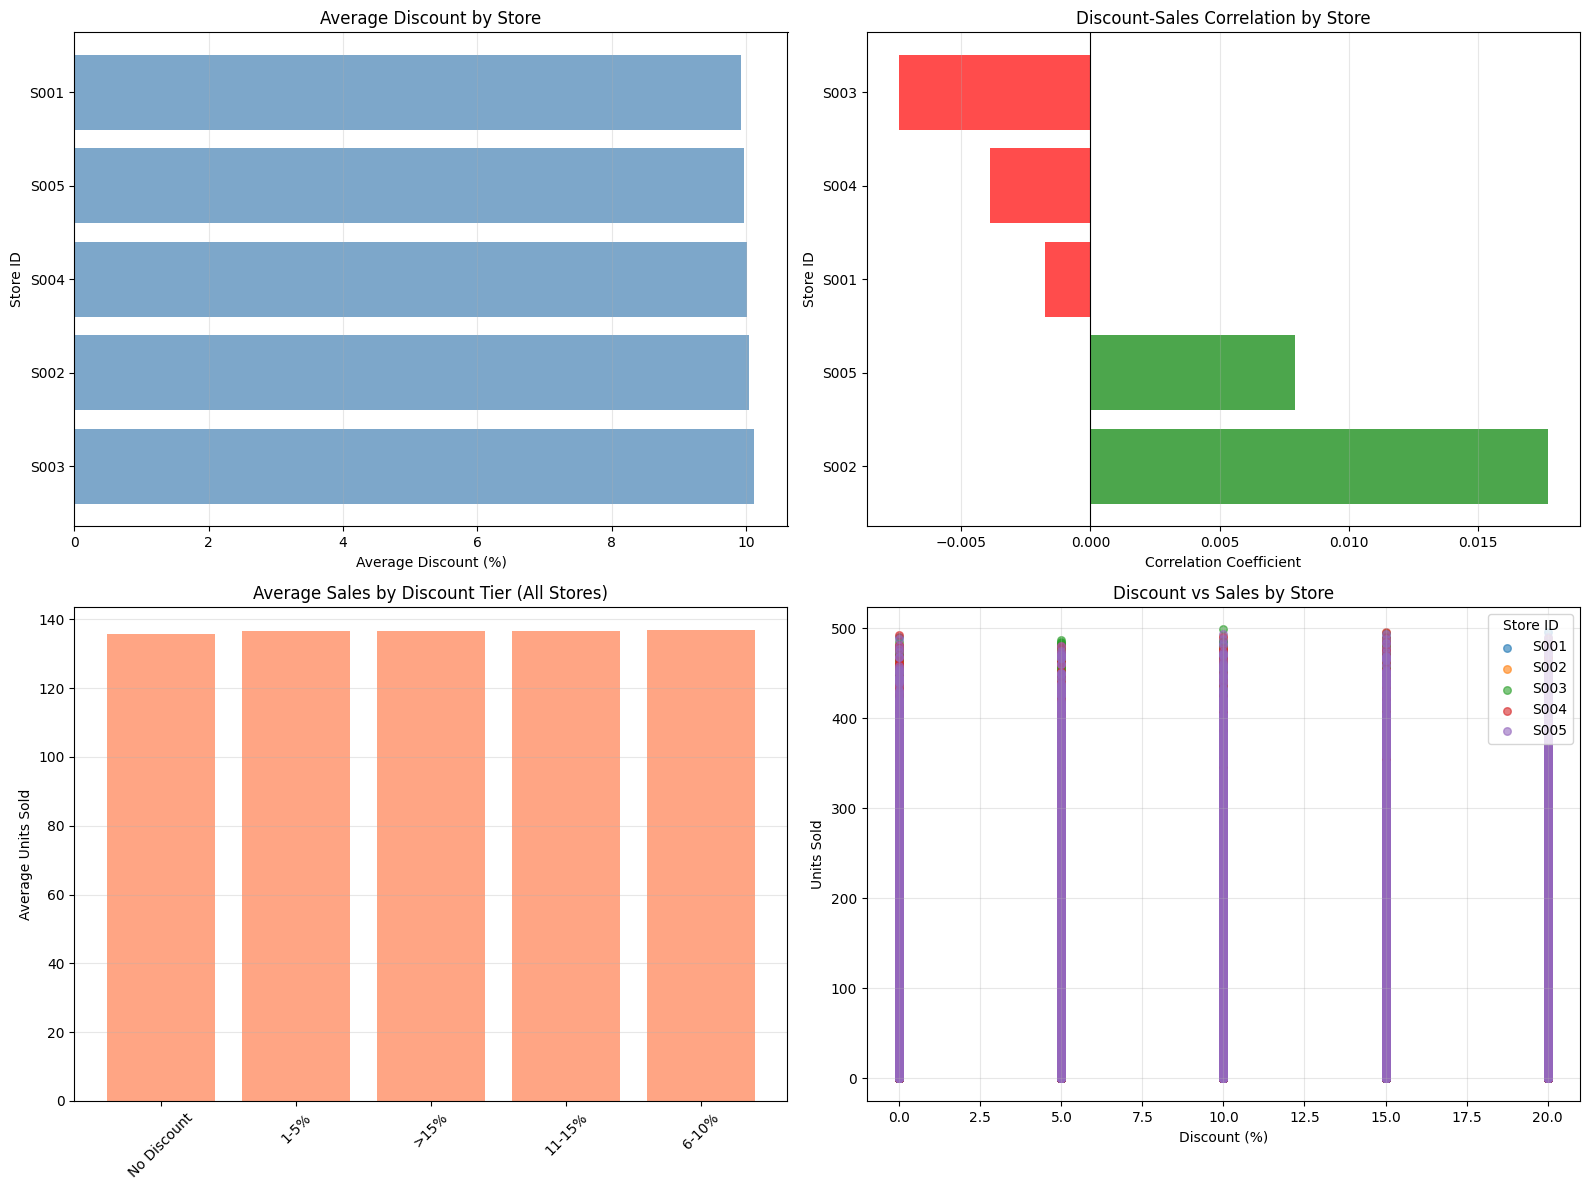



=== KEY INSIGHTS ===

1. Store with highest average discount: S003 (10.11%)
2. Store with lowest average discount: S001 (9.92%)

3. Best discount effectiveness: S002 (Correlation: 0.018)
4. Worst discount effectiveness: S003 (Correlation: -0.007)

5. No Discount avg sales: 135.69 units vs >15% Discount avg sales: 136.64 units

✓ Discount impact analysis complete!


In [53]:
# ── 11. DISCOUNT IMPACT ANALYSIS BY STORE ─────────────────────────────────
print("\n=== DISCOUNT IMPACT ANALYSIS BY STORE ===")

# 1. Average discount and sales by store
discount_analysis = df.groupby('Store ID').agg({
    'Discount': ['mean', 'min', 'max'],
    'Units Sold': 'mean',
    'Price': 'mean'
}).round(2)

discount_analysis.columns = ['Avg Discount (%)', 'Min Discount (%)', 'Max Discount (%)', 'Avg Sales (units)', 'Avg Price']
discount_analysis = discount_analysis.sort_values('Avg Discount (%)', ascending=False)

print("\nDiscount & Sales Summary by Store:")
print(discount_analysis)

# 2. Correlation between discount and sales for each store
print("\n\nDiscount-Sales Correlation by Store:")
store_correlations = []
for store in df['Store ID'].unique():
    store_data = df[df['Store ID'] == store]
    corr = store_data['Discount'].corr(store_data['Units Sold'])
    store_correlations.append({'Store ID': store, 'Discount-Sales Correlation': corr})

corr_df = pd.DataFrame(store_correlations).sort_values('Discount-Sales Correlation', ascending=False)
print(corr_df.to_string(index=False))

# 3. Sales by discount tier
df['Discount Tier'] = pd.cut(df['Discount'], bins=[-0.1, 0, 5, 10, 15, 100], 
                             labels=['No Discount', '1-5%', '6-10%', '11-15%', '>15%'])

discount_tier_analysis = df.groupby(['Store ID', 'Discount Tier']).agg({
    'Units Sold': ['count', 'mean'],
    'Price': 'mean'
}).round(2)

discount_tier_analysis.columns = ['Frequency', 'Avg Units Sold', 'Avg Price']

print("\n\nSales Performance by Discount Tier & Store:")
print(discount_tier_analysis)

# 4. Visualizations
print("\n💰 DISCOUNT STRATEGY DASHBOARD: Four visualizations analyzing discount usage patterns, their effectiveness at driving sales, and store-specific performance across different discount levels.")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Average Discount by Store
print("\n📊 PLOT 1: AVERAGE DISCOUNT BY STORE — Reveals which stores rely most heavily on discounting strategies. A higher bar indicates aggressive discount usage, which may suggest stores with weaker pricing power or different competitive positioning.")
axes[0, 0].barh(discount_analysis.index, discount_analysis['Avg Discount (%)'], color='steelblue', alpha=0.7)
axes[0, 0].set_xlabel('Average Discount (%)')
axes[0, 0].set_ylabel('Store ID')
axes[0, 0].set_title('Average Discount by Store')
axes[0, 0].grid(axis='x', alpha=0.3)

# Plot 2: Discount vs Sales Correlation by Store
print("\n📊 PLOT 2: DISCOUNT-SALES CORRELATION BY STORE — Shows whether discounts actually drive sales (green) or have minimal/negative effect (red). Positive correlation means discounting works; negative correlation indicates potential margin cannibalization without volume growth.")
colors = ['green' if x > 0 else 'red' for x in corr_df['Discount-Sales Correlation']]
axes[0, 1].barh(corr_df['Store ID'], corr_df['Discount-Sales Correlation'], color=colors, alpha=0.7)
axes[0, 1].set_xlabel('Correlation Coefficient')
axes[0, 1].set_ylabel('Store ID')
axes[0, 1].set_title('Discount-Sales Correlation by Store')
axes[0, 1].axvline(0, color='black', linestyle='-', linewidth=0.8)
axes[0, 1].grid(axis='x', alpha=0.3)

# Plot 3: Average Sales by Discount Tier
print("\n📊 PLOT 3: AVERAGE SALES BY DISCOUNT TIER (ALL STORES) — Compares average units sold across different discount brackets. If bars are roughly equal, demand is price-inelastic; if higher discounts show significantly higher sales, discounting is effective across all stores.")
discount_tier_sales = df.groupby('Discount Tier')['Units Sold'].mean().sort_values()
axes[1, 0].bar(range(len(discount_tier_sales)), discount_tier_sales.values, color='coral', alpha=0.7)
axes[1, 0].set_xticks(range(len(discount_tier_sales)))
axes[1, 0].set_xticklabels(discount_tier_sales.index, rotation=45)
axes[1, 0].set_ylabel('Average Units Sold')
axes[1, 0].set_title('Average Sales by Discount Tier (All Stores)')
axes[1, 0].grid(axis='y', alpha=0.3)

# Plot 4: Discount vs Sales by Store (Scatter)
print("\n📊 PLOT 4: DISCOUNT VS SALES SCATTER BY STORE — Visualizes the relationship between discount percentage and sales volume for each store. Upward slope indicates discounts drive sales; flat or downward slope suggests discounts ineffective or counterproductive.")
for store in sorted(df['Store ID'].unique()):
    store_data = df[df['Store ID'] == store]
    axes[1, 1].scatter(store_data['Discount'], store_data['Units Sold'], label=store, alpha=0.6, s=30)

axes[1, 1].set_xlabel('Discount (%)')
axes[1, 1].set_ylabel('Units Sold')
axes[1, 1].set_title('Discount vs Sales by Store')
axes[1, 1].legend(title='Store ID')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 5. Key insights
print("\n\n=== KEY INSIGHTS ===")
print(f"\n1. Store with highest average discount: {discount_analysis.index[0]} ({discount_analysis['Avg Discount (%)'].iloc[0]}%)")
print(f"2. Store with lowest average discount: {discount_analysis.index[-1]} ({discount_analysis['Avg Discount (%)'].iloc[-1]}%)")

highest_corr_store = corr_df.iloc[0]
print(f"\n3. Best discount effectiveness: {highest_corr_store['Store ID']} (Correlation: {highest_corr_store['Discount-Sales Correlation']:.3f})")

lowest_corr_store = corr_df.iloc[-1]
print(f"4. Worst discount effectiveness: {lowest_corr_store['Store ID']} (Correlation: {lowest_corr_store['Discount-Sales Correlation']:.3f})")

no_disc_sales = df[df['Discount Tier'] == 'No Discount']['Units Sold'].mean()
high_disc_sales = df[df['Discount Tier'] == '>15%']['Units Sold'].mean()
print(f"\n5. No Discount avg sales: {no_disc_sales:.2f} units vs >15% Discount avg sales: {high_disc_sales:.2f} units")

print("\n✓ Discount impact analysis complete!")